In [3]:
# input 
plddt_proba_file = "../../data/pred_site_plddt_proba.tsv"
# output
plddt_proba_fig = "./fig/proba_plddt.pdf"

In [4]:
import pandas as pd
df = pd.read_table(plddt_proba_file)

In [5]:
import numpy as np
plddts = df['plddt'].map(lambda x: np.median([float(i) for i in x.split(",")])).to_numpy(dtype=np.float32)
probas = df['proba'].map(lambda x: np.median([float(i) for i in x.split(",")])).to_numpy(dtype=np.float32)
# 30 min

del df

1998

In [6]:
bins = np.array([0, 50, 70, 90, 100], dtype=np.float32)
bin_labels = [f'{int(bins[i])}–{int(bins[i+1])}' for i in range(len(bins)-1)]
n_bin = len(bins) - 1
idx = np.digitize(plddts, bins, right=False) - 1
data_per_bin = [probas[idx == i] for i in range(n_bin)]

<Figure size 240x240 with 0 Axes>

/tmp/ipykernel_3477289/166402795.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_bin, labels=bin_labels, showfliers=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x73efcaacfa10>,
 'caps': [<matplotlib.lines.Line2D at 0x73efcaafa9d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x73eff9cc7850>,
 'medians': [<matplotlib.lines.Line2D at 0x73efcaab6750>,
 'fliers': [],
 'means': []}

Text(0, 0.5, 'Predicted probability')

Text(0.5, 0, 'pLDDT bins')

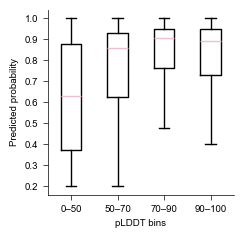

In [7]:
import matplotlib.pyplot as plt
plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

plt.figure(figsize=(2.4, 2.4))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.boxplot(data_per_bin, labels=bin_labels, showfliers=False)
plt.ylabel('Predicted probability')
plt.xlabel("pLDDT bins")
plt.savefig(plddt_proba_fig, bbox_inches="tight", transparent=True)